# Button RFI — PPO vs GTO

Compares the trained PPO agent's raise frequency on the Button (when folded to)
against the GTO 6-max 100BB BTN RFI range (~45% of hands).

**How to read the heatmap:**
- Rows = first card rank (A down to 2)
- Cols = second card rank (A down to 2)
- Above diagonal = suited hands, below = offsuit
- Green = PPO raises more than GTO, Red = PPO raises less, White = aligned

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict
from stable_baselines3 import PPO

from poker_env.env import PokerEnv, MultiAgentRunner
from poker_env.agents.baselines import RandomAgent, HeuristicAgent
from poker_env.agents.base import build_observation, decode_action
from poker_env.game import GameState, Action, ActionType, Street
from poker_env.card import RANKS

## GTO BTN RFI range (6-max, 100BB)

Sourced from published solver outputs. `1` = always raise, `0` = always fold, `0.x` = mixed.

In [2]:
# 13x13 matrix indexed by [rank1][rank2], rank 12=Ace, 0=2
# Upper triangle (i < j) = suited, lower triangle (i > j) = offsuit
# Diagonal = pocket pairs
# Based on standard GTO 6-max BTN RFI (~45% open)

RANK_NAMES = list('23456789TJQKA')  # index 0=2, 12=A

def make_gto_matrix():
    """Build 13x13 GTO raise frequency matrix for BTN RFI."""
    m = np.zeros((13, 13))

    # Pocket pairs — always raise TT+, mix below
    pair_freq = {
        12: 1.0,  # AA
        11: 1.0,  # KK
        10: 1.0,  # QQ
        9:  1.0,  # JJ
        8:  1.0,  # TT
        7:  1.0,  # 99
        6:  1.0,  # 88
        5:  1.0,  # 77
        4:  1.0,  # 66
        3:  0.9,  # 55
        2:  0.8,  # 44
        1:  0.6,  # 33
        0:  0.5,  # 22
    }
    for r, freq in pair_freq.items():
        m[r][r] = freq

    # Suited hands (upper triangle: row < col means col is higher rank)
    # Stored as m[lower_rank][higher_rank]
    suited = {
        # Ax suited
        (11, 12): 1.0,  # AKs
        (10, 12): 1.0,  # AQs
        (9,  12): 1.0,  # AJs
        (8,  12): 1.0,  # ATs
        (7,  12): 1.0,  # A9s
        (6,  12): 1.0,  # A8s
        (5,  12): 1.0,  # A7s
        (4,  12): 1.0,  # A6s
        (3,  12): 1.0,  # A5s
        (2,  12): 1.0,  # A4s
        (1,  12): 1.0,  # A3s
        (0,  12): 0.8,  # A2s
        # Kx suited
        (10, 11): 1.0,  # KQs
        (9,  11): 1.0,  # KJs
        (8,  11): 1.0,  # KTs
        (7,  11): 1.0,  # K9s
        (6,  11): 0.9,  # K8s
        (5,  11): 0.6,  # K7s
        (4,  11): 0.6,  # K6s
        (3,  11): 0.5,  # K5s
        (2,  11): 0.5,  # K4s
        (1,  11): 0.4,  # K3s
        (0,  11): 0.4,  # K2s
        # Qx suited
        (9,  10): 1.0,  # QJs
        (8,  10): 1.0,  # QTs
        (7,  10): 1.0,  # Q9s
        (6,  10): 0.7,  # Q8s
        (5,  10): 0.5,  # Q7s
        (4,  10): 0.0,  # Q6s
        (3,  10): 0.0,  # Q5s
        (2,  10): 0.4,  # Q4s
        (1,  10): 0.4,  # Q3s
        (0,  10): 0.4,  # Q2s
        # Jx suited
        (8,  9):  1.0,  # JTs
        (7,  9):  1.0,  # J9s
        (6,  9):  0.8,  # J8s
        (5,  9):  0.5,  # J7s
        (4,  9):  0.0,  # J6s
        (3,  9):  0.0,  # J5s
        (2,  9):  0.0,  # J4s
        (1,  9):  0.4,  # J3s
        (0,  9):  0.4,  # J2s
        # Tx suited
        (7,  8):  1.0,  # T9s
        (6,  8):  1.0,  # T8s
        (5,  8):  0.6,  # T7s
        (4,  8):  0.0,  # T6s
        (3,  8):  0.0,  # T5s
        (2,  8):  0.0,  # T4s
        (1,  8):  0.4,  # T3s
        (0,  8):  0.4,  # T2s
        # 9x suited
        (6,  7):  1.0,  # 98s
        (5,  7):  0.9,  # 97s
        (4,  7):  0.5,  # 96s
        (3,  7):  0.0,  # 95s
        (2,  7):  0.0,  # 94s
        # 8x suited
        (5,  6):  1.0,  # 87s
        (4,  6):  0.8,  # 86s
        (3,  6):  0.5,  # 85s
        # 7x suited
        (4,  5):  1.0,  # 76s
        (3,  5):  0.7,  # 75s
        # 6x suited
        (3,  4):  0.8,  # 65s
        (2,  4):  0.5,  # 64s
        # 5x suited
        (2,  3):  0.7,  # 54s
    }
    for (lo, hi), freq in suited.items():
        m[lo][hi] = freq  # upper triangle

    # Offsuit hands (lower triangle: m[higher_rank][lower_rank])
    offsuit = {
        # Ax offsuit
        (12, 11): 1.0,  # AKo
        (12, 10): 1.0,  # AQo
        (12, 9):  1.0,  # AJo
        (12, 8):  1.0,  # ATo
        (12, 7):  0.8,  # A9o
        (12, 6):  0.5,  # A8o
        (12, 5):  0.4,  # A7o
        (12, 4):  0.0,  # A6o
        (12, 3):  0.0,  # A5o
        (12, 2):  0.0,  # A4o
        (12, 1):  0.0,  # A3o
        (12, 0):  0.0,  # A2o
        # Kx offsuit
        (11, 10): 1.0,  # KQo
        (11, 9):  1.0,  # KJo
        (11, 8):  1.0,  # KTo
        (11, 7):  0.7,  # K9o
        (11, 6):  0.0,  # K8o
        (11, 5):  0.0,  # K7o
        (11, 4):  0.0,  # K6o
        (11, 3):  0.0,  # K5o
        (11, 2):  0.0,  # K4o
        (11, 1):  0.0,  # K3o
        (11, 0):  0.0,  # K2o
        # Qx offsuit
        (10, 9):  1.0,  # QJo
        (10, 8):  0.8,  # QTo
        (10, 7):  0.5,  # Q9o
        (10, 6):  0.0,  # Q8o
        # Jx offsuit
        (9,  8):  0.8,  # JTo
        (9,  7):  0.5,  # J9o
        (9,  6):  0.0,  # J8o
        # Tx offsuit
        (8,  7):  0.7,  # T9o
        (8,  6):  0.4,  # T8o
        # 9x offsuit
        (7,  6):  0.5,  # 98o
        (7,  5):  0.0,  # 97o
        # connectors
        (6,  5):  0.4,  # 87o
    }
    for (hi, lo), freq in offsuit.items():
        m[hi][lo] = freq  # lower triangle

    return m

GTO = make_gto_matrix()
print(f"GTO range covers {GTO.mean()*100:.1f}% of combos on average")
print(f"(target ~45% for BTN RFI)")

GTO range covers 40.1% of combos on average
(target ~45% for BTN RFI)


## Collect PPO decisions at BTN RFI spots

In [3]:
# Swap MODEL_PATH to compare different training runs:
MODEL_PATH = "../models/ppo_poker_final"            # ← current model (86-dim obs)

import torch
model = PPO.load(MODEL_PATH)
print(f"Loaded: {MODEL_PATH}")

# ─────────────────────────────────────────────────────────────────────────────
# Synthetic BTN RFI observation — 86-dim format
# ─────────────────────────────────────────────────────────────────────────────

def build_rfi_obs(card1: int, card2: int, pos_rel: int = 0) -> np.ndarray:
    """Build 86-dim BTN RFI observation. pos_rel=0 means hero is on the button."""
    obs = np.zeros(86, dtype=np.float32)
    bb, stack = 10, 1000
    NORM = bb * 100

    obs[0] = 0.0
    obs[1] = 15 / NORM
    obs[2] = bb / NORM
    obs[3] = stack / NORM
    obs[4] = 0.0
    obs[5] = pos_rel / 5.0

    r0, r1 = card1 // 4, card2 // 4
    s0, s1 = card1 % 4,  card2 % 4
    obs[6] = max(r0, r1) / 12.0
    obs[7] = min(r0, r1) / 12.0
    obs[8] = 1.0 if (s0 == s1 and r0 != r1) else 0.0
    obs[9] = 1.0 if r0 == r1 else 0.0

    for i in range(5):
        obs[62 + i] = stack / NORM
        obs[68 + i] = (5 if i == 0 else 10 if i == 1 else 0) / NORM
        obs[74 + i] = 0.0
        obs[80 + i] = 0.0

    return obs


def get_raise_prob(card1: int, card2: int) -> float:
    """Return the policy raise probability (actions 2+3+4) for a given hand."""
    obs = build_rfi_obs(card1, card2, pos_rel=0)
    device = next(model.policy.parameters()).device
    obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
    with torch.no_grad():
        dist = model.policy.get_distribution(obs_t)
        probs = dist.distribution.probs.squeeze().cpu().numpy()
    return float(probs[2] + probs[3] + probs[4])


def collect_btn_rfi_raise_probs():
    """Probe all 169 canonical hands; return dict (rh, rl, suited) -> raise_prob."""
    result = {}
    for rank1 in range(13):        # low rank
        for rank2 in range(rank1, 13):  # high rank
            if rank1 == rank2:
                p = get_raise_prob(rank1 * 4 + 0, rank2 * 4 + 1)
                result[(rank2, rank1, False)] = p
            else:
                p_s = get_raise_prob(rank1 * 4 + 0, rank2 * 4 + 0)
                result[(rank2, rank1, True)]  = p_s
                p_o = get_raise_prob(rank1 * 4 + 0, rank2 * 4 + 1)
                result[(rank2, rank1, False)] = p_o

    print(f"Collected raise probabilities for {len(result)} hand types")
    mean_p = np.mean(list(result.values()))
    print(f"Mean raise probability: {mean_p*100:.1f}%")
    return result

raise_probs = collect_btn_rfi_raise_probs()


Loaded: ../models/ppo_poker_final
Collected raise probabilities for 169 hand types
Mean raise probability: 43.1%


/home/horn/Desktop/GIT-repo/rl-pokerlab/.venv/lib/python3.14/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## Build PPO raise frequency matrix

In [4]:
def build_ppo_matrix(raise_probs):
    """Convert raise probability dict to 13x13 matrix."""
    m = np.full((13, 13), np.nan)

    for (r1, r2, suited), prob in raise_probs.items():
        if r1 == r2:                  # pocket pair — diagonal
            m[r1][r2] = prob
        elif suited:                  # suited — upper triangle
            m[r2][r1] = prob
        else:                         # offsuit — lower triangle
            m[r1][r2] = prob

    return m

PPO_MATRIX = build_ppo_matrix(raise_probs)

has_data = ~np.isnan(PPO_MATRIX)
print(f"Hand combos with data: {has_data.sum()} / 169")
valid = PPO_MATRIX[has_data]
print(f"PPO overall raise frequency: {valid.mean()*100:.1f}%")
print(f"GTO overall raise frequency: {GTO[has_data].mean()*100:.1f}%")


Hand combos with data: 169 / 169
PPO overall raise frequency: 43.1%
GTO overall raise frequency: 40.1%


## Heatmap: PPO raise frequency

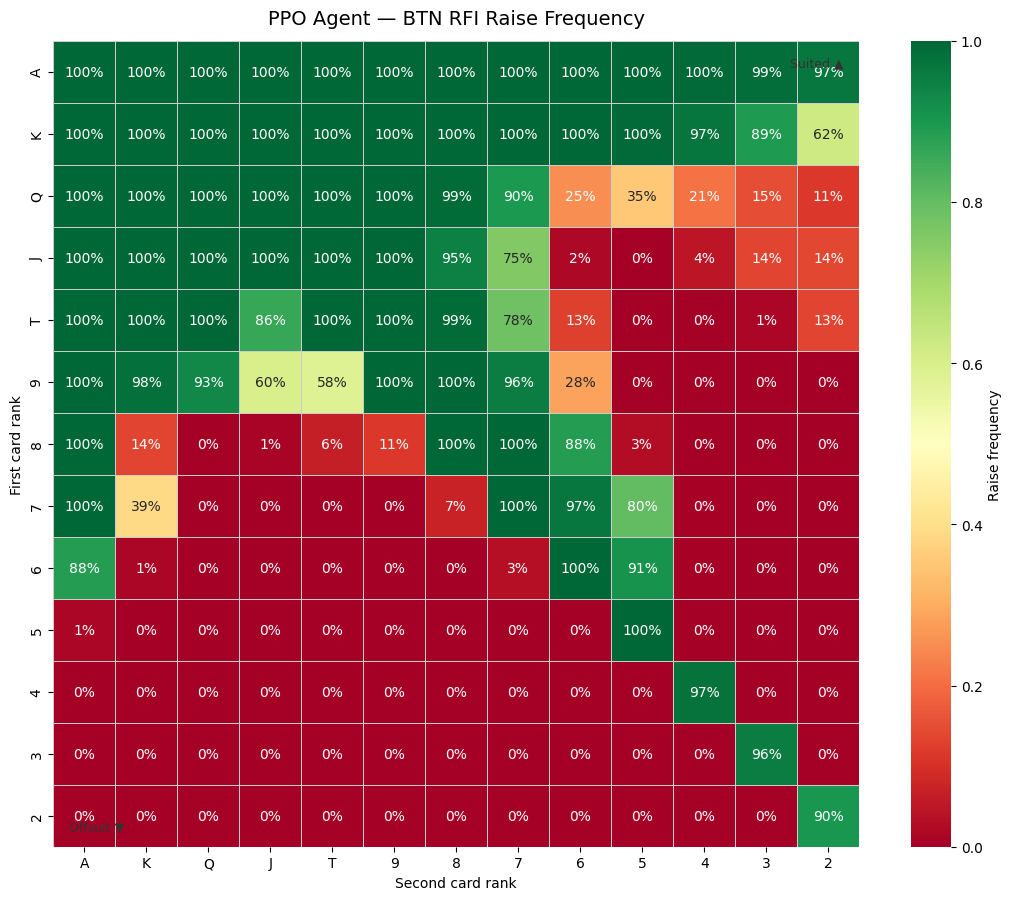

In [5]:
RANK_LABELS = list(reversed(RANK_NAMES))  # A down to 2 for display

def plot_matrix(matrix, title, cmap='RdYlGn', vmin=0, vmax=1, annot=True):
    # Transpose + double-flip so both axes run A→2.
    # Storage convention: suited at m[lo][hi] (upper triangle),
    # offsuit at m[hi][lo] (lower triangle).
    # After .T[::-1, ::-1]: suited lands upper-right, offsuit lower-left,
    # AA at top-left — matches the standard poker hand grid.
    display = matrix.T[::-1, ::-1]

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        display,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=annot,
        fmt='.0%' if annot else '',
        linewidths=0.5,
        linecolor='#cccccc',
        cbar_kws={'label': 'Raise frequency'},
        xticklabels=RANK_LABELS,
        yticklabels=RANK_LABELS,
        square=True,
    )
    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('Second card rank')
    ax.set_ylabel('First card rank')

    ax.text(0.98, 0.98, 'Suited ▲', transform=ax.transAxes,
            fontsize=9, va='top', ha='right', color='#333333')
    ax.text(0.02, 0.02, 'Offsuit ▼', transform=ax.transAxes,
            fontsize=9, ha='left', color='#333333')
    plt.tight_layout()
    return fig

fig1 = plot_matrix(PPO_MATRIX, 'PPO Agent — BTN RFI Raise Frequency')
plt.savefig('ppo_btn_rfi.png', dpi=150, bbox_inches='tight')
plt.show()

## Heatmap: GTO range

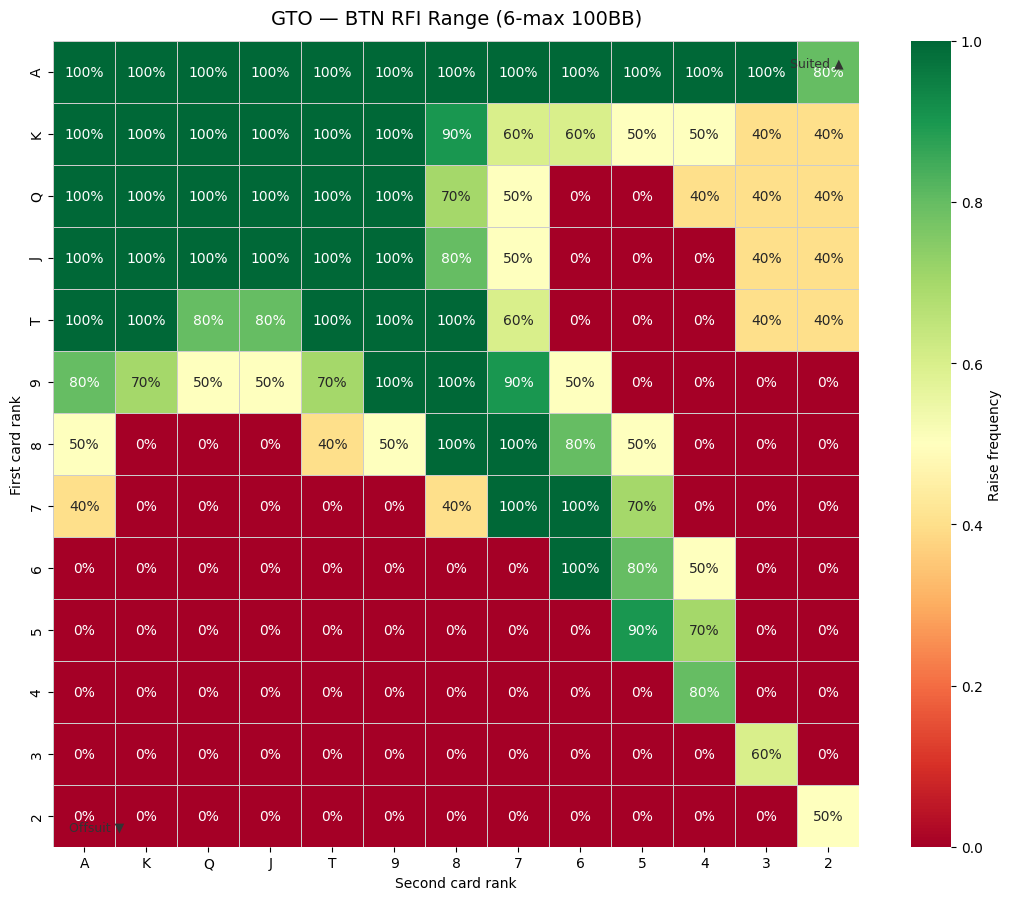

In [6]:
fig2 = plot_matrix(GTO, 'GTO — BTN RFI Range (6-max 100BB)')
plt.savefig('gto_btn_rfi.png', dpi=150, bbox_inches='tight')
plt.show()

## Heatmap: Deviation (PPO − GTO)

Green = PPO over-raises vs GTO. Red = PPO under-raises (folds too much).

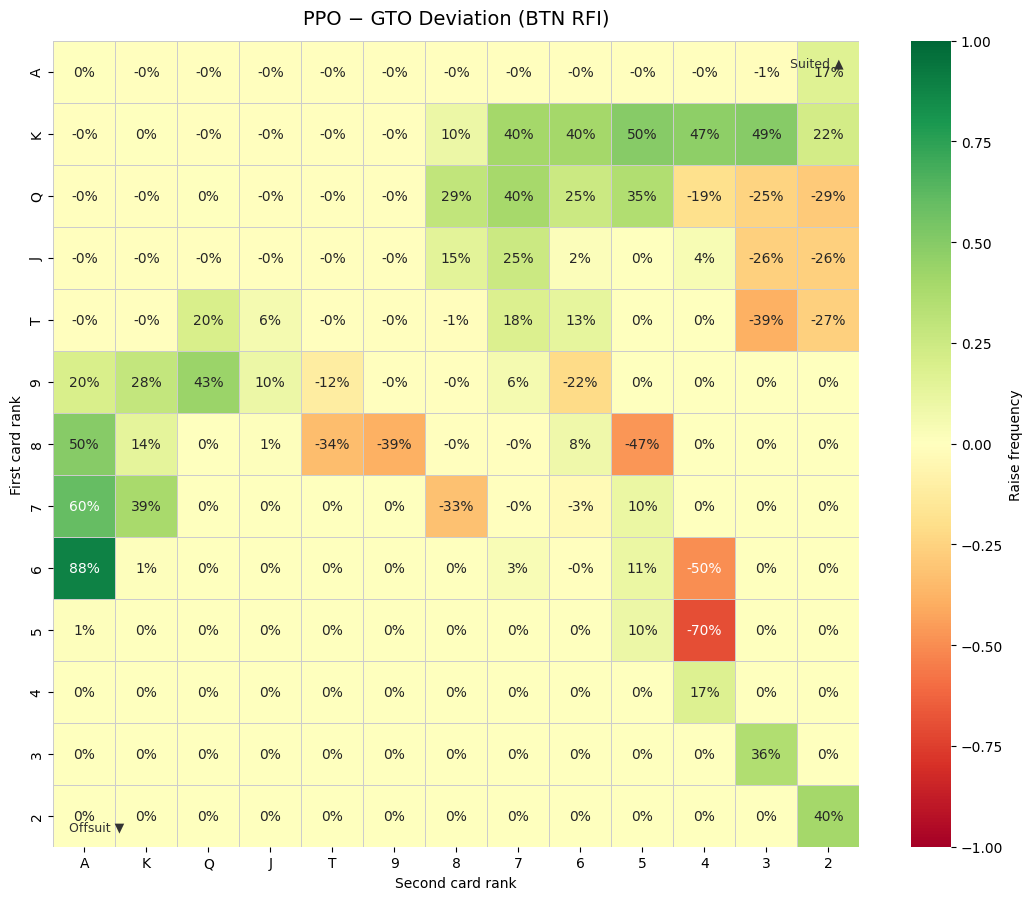

In [7]:
DEVIATION = PPO_MATRIX - GTO

fig3 = plot_matrix(
    DEVIATION,
    'PPO − GTO Deviation (BTN RFI)',
    cmap='RdYlGn',
    vmin=-1,
    vmax=1,
)
plt.savefig('deviation_btn_rfi.png', dpi=150, bbox_inches='tight')
plt.show()

## Top deviations — biggest leaks

In [8]:
def combo_name(r1, r2, suited):
    if r1 == r2:
        return RANK_NAMES[r1] * 2
    high, low = max(r1, r2), min(r1, r2)
    suffix = "s" if suited else "o"
    return f"{RANK_NAMES[high]}{RANK_NAMES[low]}{suffix}"

rows = []
for (r1, r2, suited), ppo_freq in raise_probs.items():
    if r1 == r2:
        gto_freq = GTO[r1][r2]
    elif suited:
        gto_freq = GTO[r2][r1]
    else:
        gto_freq = GTO[r1][r2]

    deviation = ppo_freq - gto_freq
    rows.append({
        "Hand": combo_name(r1, r2, suited),
        "PPO":  f"{ppo_freq:.0%}",
        "GTO":  f"{gto_freq:.0%}",
        "Deviation": f"{deviation:+.0%}",
        "_dev": deviation,
    })

rows.sort(key=lambda x: abs(x["_dev"]), reverse=True)

print(f"{'Hand':<8} {'PPO':>6} {'GTO':>6} {'Deviation':>10}")
print("-" * 38)
for r in rows[:20]:
    print(f"{r['Hand']:<8} {r['PPO']:>6} {r['GTO']:>6} {r['Deviation']:>10}")


Hand        PPO    GTO  Deviation
--------------------------------------
A6o         88%     0%       +88%
54s          0%    70%       -70%
A7o        100%    40%       +60%
A8o        100%    50%       +50%
K5s        100%    50%       +50%
64s          0%    50%       -50%
K3s         89%    40%       +49%
85s          3%    50%       -47%
K4s         97%    50%       +47%
Q9o         93%    50%       +43%
K7s        100%    60%       +40%
K6s        100%    60%       +40%
22          90%    50%       +40%
Q7s         90%    50%       +40%
K7o         39%     0%       +39%
T3s          1%    40%       -39%
98o         11%    50%       -39%
33          96%    60%       +36%
Q5s         35%     0%       +35%
T8o          6%    40%       -34%


## Summary

In [9]:
over_raises  = [(r, d) for r in rows for d in [r['_dev']] if d >  0.15]
under_raises = [(r, d) for r in rows for d in [r['_dev']] if d < -0.15]

print(f"Hands PPO significantly over-raises vs GTO (>15%):")
for r, _ in sorted(over_raises, key=lambda x: -x[1]):
    print(f"  {r['Hand']}: PPO={r['PPO']} GTO={r['GTO']}")

print(f"\nHands PPO significantly under-raises vs GTO (>15% below):")
for r, _ in sorted(under_raises, key=lambda x: x[1]):
    print(f"  {r['Hand']}: PPO={r['PPO']} GTO={r['GTO']}")

Hands PPO significantly over-raises vs GTO (>15%):
  A6o: PPO=88% GTO=0%
  A7o: PPO=100% GTO=40%
  A8o: PPO=100% GTO=50%
  K5s: PPO=100% GTO=50%
  K3s: PPO=89% GTO=40%
  K4s: PPO=97% GTO=50%
  Q9o: PPO=93% GTO=50%
  K7s: PPO=100% GTO=60%
  K6s: PPO=100% GTO=60%
  22: PPO=90% GTO=50%
  Q7s: PPO=90% GTO=50%
  K7o: PPO=39% GTO=0%
  33: PPO=96% GTO=60%
  Q5s: PPO=35% GTO=0%
  Q8s: PPO=99% GTO=70%
  K9o: PPO=98% GTO=70%
  J7s: PPO=75% GTO=50%
  Q6s: PPO=25% GTO=0%
  K2s: PPO=62% GTO=40%
  A9o: PPO=100% GTO=80%
  QTo: PPO=100% GTO=80%
  T7s: PPO=78% GTO=60%
  44: PPO=97% GTO=80%
  A2s: PPO=97% GTO=80%

Hands PPO significantly under-raises vs GTO (>15% below):
  54s: PPO=0% GTO=70%
  64s: PPO=0% GTO=50%
  85s: PPO=3% GTO=50%
  T3s: PPO=1% GTO=40%
  98o: PPO=11% GTO=50%
  T8o: PPO=6% GTO=40%
  87o: PPO=7% GTO=40%
  Q2s: PPO=11% GTO=40%
  T2s: PPO=13% GTO=40%
  J3s: PPO=14% GTO=40%
  J2s: PPO=14% GTO=40%
  Q3s: PPO=15% GTO=40%
  96s: PPO=28% GTO=50%
  Q4s: PPO=21% GTO=40%
